# Maersk Depot Segmentation & Profitability Analysis
### CMU MSBA Capstone 2025 -- Deepak Reddy, Ethan Wong, Mehdi Abbas, Ziheng Wu

**Objective:** Segment 50 inland container depots into structurally distinct groups, identify
the drivers of GP margin variance, and quantify migration pathways to guide investment decisions.

**Analytical approach:**
1. K-Means clustering on 14 operational & financial features (validated with hierarchical clustering)
2. Random Forest + SHAP to rank GP margin drivers globally and per segment
3. OLS / Ridge regression to quantify per-product revenue uplift for migration pathways
4. Exploratory data analysis on the full network

**Data files required (same folder as this notebook):**
- `Master_List_of_depots.csv`
- `Revenue_2023_2025.csv`
- `GP_2024_2025.csv`

## 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import spearmanr
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

SEG_COLORS = {'A':'#C0392B','B':'#E67E22','C':'#2980B9','D':'#16A085','E':'#27AE60'}
SEG_NAMES  = {
    'A':'Volume Leaders', 'B':'Diversified Mid-Hubs',
    'C':'Core Storage & EMR', 'D':'Lean Specialists', 'E':'High-Margin Niche'
}
print("Imports OK")

Imports OK


## 2. Data Loading

In [ ]:
depot_master = pd.read_csv('Master_List_of_depots.csv', encoding='utf-8-sig')
revenue_data = pd.read_csv('Revenue_2023_2025.csv',     encoding='utf-8-sig')
gp_data      = pd.read_csv('GP_2024_2025.csv',          encoding='utf-8-sig')

print(f"Depot Master : {depot_master.shape[0]} depots  x  {depot_master.shape[1]} columns")
print(f"Revenue Data : {revenue_data.shape[0]} rows   x  {revenue_data.shape[1]} columns  (monthly 2023-2025)")
print(f"GP Data      : {gp_data.shape[0]} rows   x  {gp_data.shape[1]} columns  (monthly 2024-2025)")
print(f"Countries    : {depot_master['Country'].nunique()}")
print(f"Regions      : {depot_master['Region'].nunique()}")
print(f"Active depots: {(depot_master['Site_Status']=='Active').sum()}")

Depot Master : 50 depots  x  17 columns
Revenue Data : 50 rows   x  38 columns  (monthly 2023-2025)
GP Data      : 50 rows   x  26 columns  (monthly 2024-2025)
Countries    : 28
Regions      : 5
Active depots: 50


## 3. Data Preparation

In [ ]:
# ---- Revenue aggregation ----------------------------------------------------
revenue_data = revenue_data.replace('NULL', np.nan)
for col in [c for c in revenue_data.columns if c not in ['Site_ID','Site_Name']]:
    revenue_data[col] = pd.to_numeric(revenue_data[col], errors='coerce')

rev_2023_cols = [c for c in revenue_data.columns if '2023' in c]
rev_2024_cols = [c for c in revenue_data.columns if '2024' in c]
rev_2025_cols = [c for c in revenue_data.columns if '2025' in c]

revenue_data['Revenue_2023']    = revenue_data[rev_2023_cols].sum(axis=1)
revenue_data['Revenue_2024']    = revenue_data[rev_2024_cols].sum(axis=1)
revenue_data['Revenue_2025']    = revenue_data[rev_2025_cols].sum(axis=1)
revenue_data['Revenue_Total']   = (revenue_data['Revenue_2023']
                                 + revenue_data['Revenue_2024']
                                 + revenue_data['Revenue_2025'])
revenue_data['Revenue_3yr_avg'] = revenue_data['Revenue_Total'] / 3
revenue_data['YoY_Growth_Pct']  = (
    (revenue_data['Revenue_2024'] - revenue_data['Revenue_2023'])
    / revenue_data['Revenue_2023'] * 100
)

# ---- GP aggregation ---------------------------------------------------------
# NOTE: GP data covers 2024-2025 only. No 2023 GP available.
gp_data = gp_data.replace('NULL', np.nan)
for col in [c for c in gp_data.columns if c not in ['Site_ID','Site_Name']]:
    gp_data[col] = pd.to_numeric(gp_data[col], errors='coerce')

gp_data['GP_2024']  = gp_data[[c for c in gp_data.columns if '2024' in c]].sum(axis=1)
gp_data['GP_2025']  = gp_data[[c for c in gp_data.columns if '2025' in c]].sum(axis=1)
gp_data['GP_Total'] = gp_data['GP_2024'] + gp_data['GP_2025']

# ---- Merge ------------------------------------------------------------------
df = depot_master.copy()
df = df.merge(
    revenue_data[['Site_ID','Revenue_2023','Revenue_2024','Revenue_2025',
                  'Revenue_Total','Revenue_3yr_avg','YoY_Growth_Pct']],
    on='Site_ID', how='left'
)
df = df.merge(gp_data[['Site_ID','GP_2024','GP_2025','GP_Total']], on='Site_ID', how='left')

# ---- GP Margin --------------------------------------------------------------
# GP_Margin_2024    = single-year 2024  --> used as RF TARGET
# GP_Margin_2yr_avg = (GP_2024+GP_2025)/(Rev_2024+Rev_2025) --> used in clustering & profiles
df['GP_Margin_2024']    = df['GP_2024'] / df['Revenue_2024'] * 100
df['GP_Margin_2025']    = df['GP_2025'] / df['Revenue_2025'] * 100
df['GP_Margin_2yr_avg'] = df['GP_Total'] / (df['Revenue_2024'] + df['Revenue_2025']) * 100
df['GP_Margin_Total']   = df['GP_Margin_2yr_avg']   # alias used in clustering

print(f"Unified dataset: {df.shape[0]} depots x {df.shape[1]} columns")
print()
print(f"  Total revenue 2023-2025 : ${revenue_data['Revenue_Total'].sum():>15,.0f}")
print(f"  Total revenue 2024      : ${revenue_data['Revenue_2024'].sum():>15,.0f}")
print(f"  Total GP 2024           : ${gp_data['GP_2024'].sum():>15,.0f}")
print(f"  Network GP margin 2024  : {gp_data['GP_2024'].sum()/revenue_data['Revenue_2024'].sum()*100:.1f}%")
print(f"  Highest depot rev 2024  : ${revenue_data['Revenue_2024'].max():>15,.0f}")
print(f"  Median depot rev 2024   : ${revenue_data['Revenue_2024'].median():>15,.0f}")

Unified dataset: 50 depots x 30 columns

  Total revenue 2023-2025 : $  1,194,060,686
  Total revenue 2024      : $    395,415,071
  Total GP 2024           : $    221,590,162
  Network GP margin 2024  : 56.0%
  Highest depot rev 2024  : $     57,257,002
  Median depot rev 2024   : $      5,605,606


## 4. Feature Engineering

In [ ]:
def parse_list(s, sep=';#'):
    if pd.isna(s) or str(s).strip() == '':
        return []
    return [x.strip().lower() for x in str(s).split(sep)]

df['Products_List'] = df['Products_Solutions_Offered'].apply(parse_list)
df['DAPS_List']     = df['Breakdown_of_DAPS'].apply(parse_list)

# ---- Product features -------------------------------------------------------
# IMPORTANT: separator is ';#', not comma.
# Reefer is stored in Breakdown_of_DAPS, NOT in the main products field.
df['Product_Count']      = df['Products_List'].apply(len)
df['Has_EMR']            = df['Products_List'].apply(lambda x: int(any('emr' in p for p in x)))
df['Has_Empty_Storage']  = df['Products_List'].apply(lambda x: int(any('empty container storage' in p for p in x)))
df['Has_Full_Storage']   = df['Products_List'].apply(lambda x: int(any('full container storage' in p for p in x)))
df['Has_Stuffing']       = df['Products_List'].apply(lambda x: int(any('stuffing' in p for p in x)))
df['Has_Accessories']    = df['Products_List'].apply(lambda x: int(any('accessor' in p or 'premium' in p for p in x)))
df['Has_Container_Prep'] = df['Products_List'].apply(lambda x: int(any('container preparation' in p for p in x)))
df['Has_Reefer']         = df['DAPS_List'].apply(lambda x: int(any('reefer' in p for p in x)))

# ---- Connectivity -----------------------------------------------------------
conn = df['Connected_service_with'].fillna('').str.lower()
df['Connected_Truck'] = conn.apply(lambda x: int('truck' in x))
df['Connected_Rail']  = conn.apply(lambda x: int('rail'  in x))
df['Is_Bonded']       = df['Bonded_Depot_Yard'].fillna('').str.lower().apply(lambda x: int('yes' in x))

# ---- Physical ---------------------------------------------------------------
df['Site_m']           = pd.to_numeric(df['Site_m'],           errors='coerce')
df['Max_TEU_Capacity'] = pd.to_numeric(df['Max_TEU_Capacity'], errors='coerce')
df['Max_FFE_Capacity'] = pd.to_numeric(df['Max_FFE_Capacity'], errors='coerce')
df['Revenue_per_sqm']  = df['Revenue_2024'] / df['Site_m'].replace(0, np.nan)

# ---- Sanity check -----------------------------------------------------------
active = df[df['Site_Status'] == 'Active']
print(f"Active depots: {len(active)}  |  Countries: {active['Country'].nunique()}")
print()
print("Service penetration (active network):")
for f in ['Has_EMR','Has_Empty_Storage','Has_Full_Storage','Has_Stuffing',
          'Has_Reefer','Has_Accessories','Has_Container_Prep','Connected_Rail','Is_Bonded']:
    n = active[f].sum()
    print(f"  {f:<25}: {n:2d}/50 ({n/len(active)*100:.0f}%)")
print(f"  {'Product_Count (mean)':<25}: {active['Product_Count'].mean():.1f}  (range {active['Product_Count'].min()}-{active['Product_Count'].max()})")

Active depots: 50  |  Countries: 28

Service penetration (active network):
  Has_EMR                  : 39/50 (78%)
  Has_Empty_Storage        : 42/50 (84%)
  Has_Full_Storage         : 36/50 (72%)
  Has_Stuffing             : 30/50 (60%)
  Has_Reefer               : 20/50 (40%)
  Has_Accessories          : 44/50 (88%)
  Has_Container_Prep       : 19/50 (38%)
  Connected_Rail           : 11/50 (22%)
  Is_Bonded                : 10/50 (20%)
  Product_Count (mean)     : 4.5  (range 1-8)


## 5. Exploratory Data Analysis

=== REGIONAL BREAKDOWN ===
  Latin America Region                      : 21 depots (42%)
  India, Middle East, and Africa            : 16 depots (32%)
  Europe Region                             :  8 depots (16%)
  North America Region                      :  3 depots (6%)
  Asia Pacific Region                       :  2 depots (4%)

=== YoY REVENUE GROWTH (2023->2024) ===
  Depots with 2023 baseline: 35
  Grew YoY (positive)      : 22
  Contracted               : 13
  Median YoY growth        : +13.3%


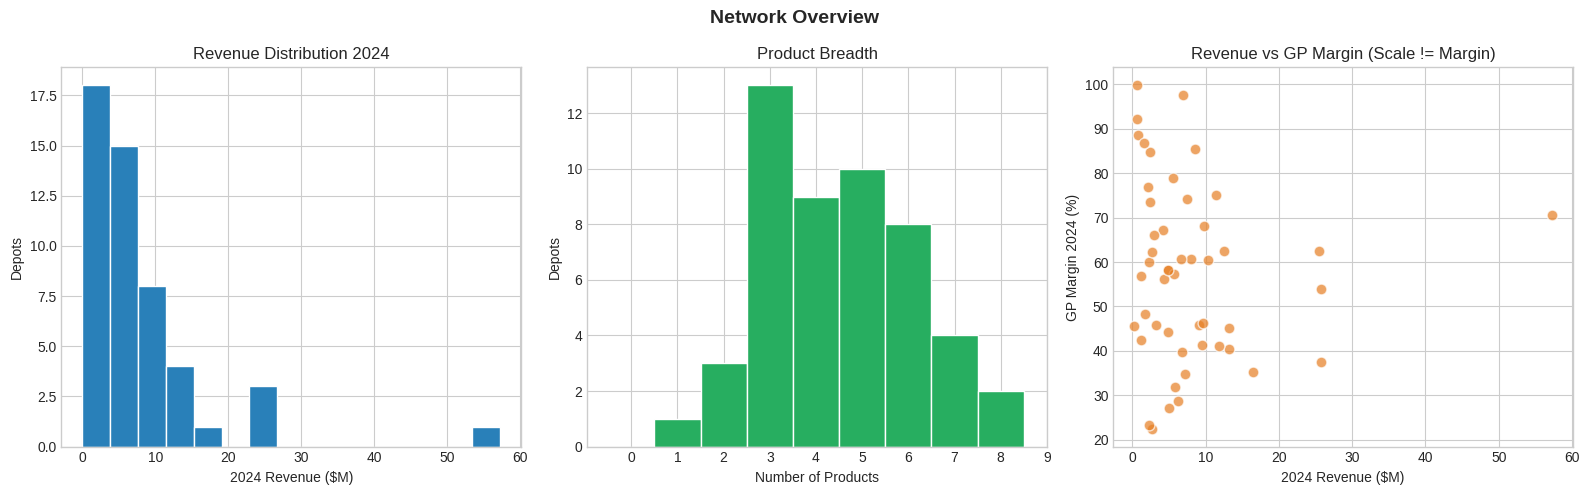

In [ ]:
active = df[df['Site_Status'] == 'Active'].copy()

print("=== REGIONAL BREAKDOWN ===")
for region, count in active.groupby('Region')['Site_ID'].count().sort_values(ascending=False).items():
    print(f"  {region:<42}: {count:2d} depots ({count/len(active)*100:.0f}%)")

print("\n=== YoY REVENUE GROWTH (2023->2024) ===")
growth = active[active['Revenue_2023'] > 0]['YoY_Growth_Pct']
print(f"  Depots with 2023 baseline: {len(growth)}")
print(f"  Grew YoY (positive)      : {(growth > 0).sum()}")
print(f"  Contracted               : {(growth < 0).sum()}")
print(f"  Median YoY growth        : {growth.median():+.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Network Overview', fontsize=14, fontweight='bold')

axes[0].hist(active['Revenue_2024'] / 1e6, bins=15, color='#2980B9', edgecolor='white')
axes[0].set_xlabel('2024 Revenue ($M)'); axes[0].set_ylabel('Depots')
axes[0].set_title('Revenue Distribution 2024')

axes[1].hist(active['Product_Count'], bins=range(0,10), color='#27AE60',
             edgecolor='white', align='left')
axes[1].set_xlabel('Number of Products'); axes[1].set_ylabel('Depots')
axes[1].set_title('Product Breadth'); axes[1].set_xticks(range(0,10))

valid = active[active['Revenue_2024'] > 0]
axes[2].scatter(valid['Revenue_2024']/1e6, valid['GP_Margin_2024'],
                alpha=0.7, color='#E67E22', edgecolors='white', s=60)
axes[2].set_xlabel('2024 Revenue ($M)'); axes[2].set_ylabel('GP Margin 2024 (%)')
axes[2].set_title('Revenue vs GP Margin (Scale != Margin)')

plt.tight_layout(); plt.show()

## 6. K-Means Segmentation
### 6a. Optimal k selection


  k    Silhouette    Davies-Bouldin       Inertia
--------------------------------------------------
  2        0.1836            1.8705        514.69  <- best silhouette
  3        0.1982            1.3786        419.68  <- best silhouette
  4        0.2245            1.3408        352.52  <- best silhouette
  5        0.2354            1.3845        305.97  <- best silhouette
  6        0.2028            1.4139        278.19
  7        0.2200            1.2777        245.14
  8        0.2343            1.1614        225.56

Selected k = 5  (silhouette = 0.2354)


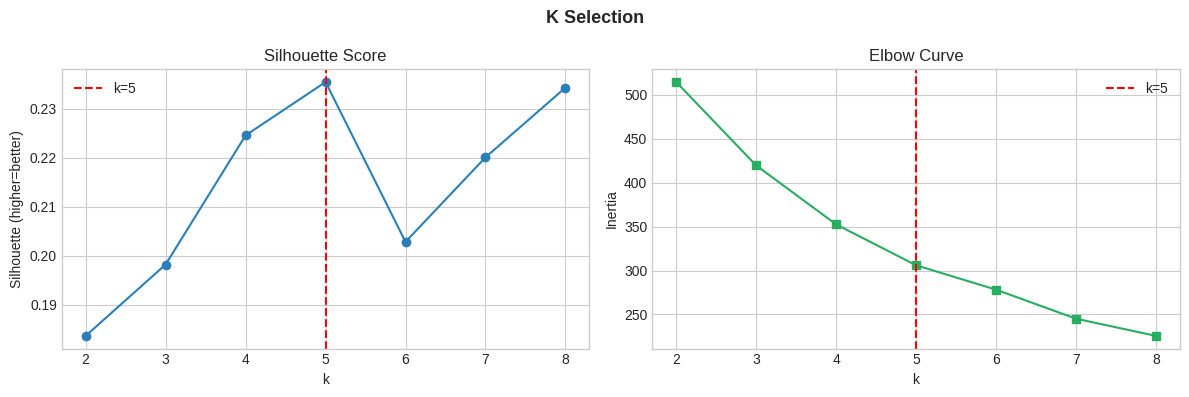

In [ ]:
df_cluster = df[df['Site_Status'] == 'Active'].copy().reset_index(drop=True)

# 14 clustering features
# Note: GP_Margin_Total (2yr blended) is included so financial behaviour
# is captured in the clusters. The supervised RF model uses GP_Margin_2024
# as its target -- a separate field -- so there is no data leakage.
CLUSTERING_FEATURES = [
    'Revenue_Total',    'GP_Margin_Total',
    'Site_m',           'Max_TEU_Capacity',  'Max_FFE_Capacity',
    'Product_Count',    'Has_EMR',           'Has_Empty_Storage',
    'Has_Full_Storage', 'Has_Stuffing',      'Has_Reefer',
    'Connected_Truck',  'Connected_Rail',    'Is_Bonded'
]

for col in CLUSTERING_FEATURES:
    if df_cluster[col].isnull().sum() > 0:
        med = df_cluster[col].median()
        df_cluster[col] = df_cluster[col].fillna(med)
        print(f"  Imputed {col:<25} with median={med:.2f}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[CLUSTERING_FEATURES])

print(f"\n{'k':>3}  {'Silhouette':>12}  {'Davies-Bouldin':>16}  {'Inertia':>12}")
print("-" * 50)
k_metrics = {}
for k in range(2, 9):
    km_t   = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    labels = km_t.fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    db     = davies_bouldin_score(X_scaled, labels)
    k_metrics[k] = {'sil': sil, 'db': db, 'inertia': km_t.inertia_}
    best = '  <- best silhouette' if sil == max(v['sil'] for v in k_metrics.values()) else ''
    print(f"  {k}  {sil:>12.4f}  {db:>16.4f}  {km_t.inertia_:>12.2f}{best}")

optimal_k = max(k_metrics, key=lambda k: k_metrics[k]['sil'])
print(f"\nSelected k = {optimal_k}  (silhouette = {k_metrics[optimal_k]['sil']:.4f})")

# Elbow + silhouette plot
ks = list(k_metrics.keys())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('K Selection', fontsize=13, fontweight='bold')
ax1.plot(ks, [k_metrics[k]['sil']    for k in ks], 'o-', color='#2980B9')
ax1.axvline(optimal_k, color='red', linestyle='--', label=f'k={optimal_k}')
ax1.set_xlabel('k'); ax1.set_ylabel('Silhouette (higher=better)'); ax1.set_title('Silhouette Score')
ax1.legend()
ax2.plot(ks, [k_metrics[k]['inertia'] for k in ks], 's-', color='#27AE60')
ax2.axvline(optimal_k, color='red', linestyle='--', label=f'k={optimal_k}')
ax2.set_xlabel('k'); ax2.set_ylabel('Inertia'); ax2.set_title('Elbow Curve')
ax2.legend()
plt.tight_layout(); plt.show()

### 6b. Fit final model & assign segments

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42, max_iter=300)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

centers_orig = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                              columns=CLUSTERING_FEATURES)
revenue_rank = centers_orig.sort_values('Revenue_Total', ascending=False).index.tolist()
segment_map  = {c: lbl for c, lbl in zip(revenue_rank, list('ABCDE')[:optimal_k])}
df_cluster['Segment'] = df_cluster['Cluster'].map(segment_map)

print("Segment distribution:")
for seg in sorted(df_cluster['Segment'].unique()):
    n = (df_cluster['Segment'] == seg).sum()
    print(f"  Segment {seg} -- {SEG_NAMES[seg]}: {n} depots")

Segment distribution:
  Segment A -- Volume Leaders: 3 depots
  Segment B -- Diversified Mid-Hubs: 6 depots
  Segment C -- Core Storage & EMR: 19 depots
  Segment D -- Lean Specialists: 15 depots
  Segment E -- High-Margin Niche: 7 depots


### 6c. PCA validation plot

PCA: PC1=34.1%  PC2=16.8%  Total=51.0%


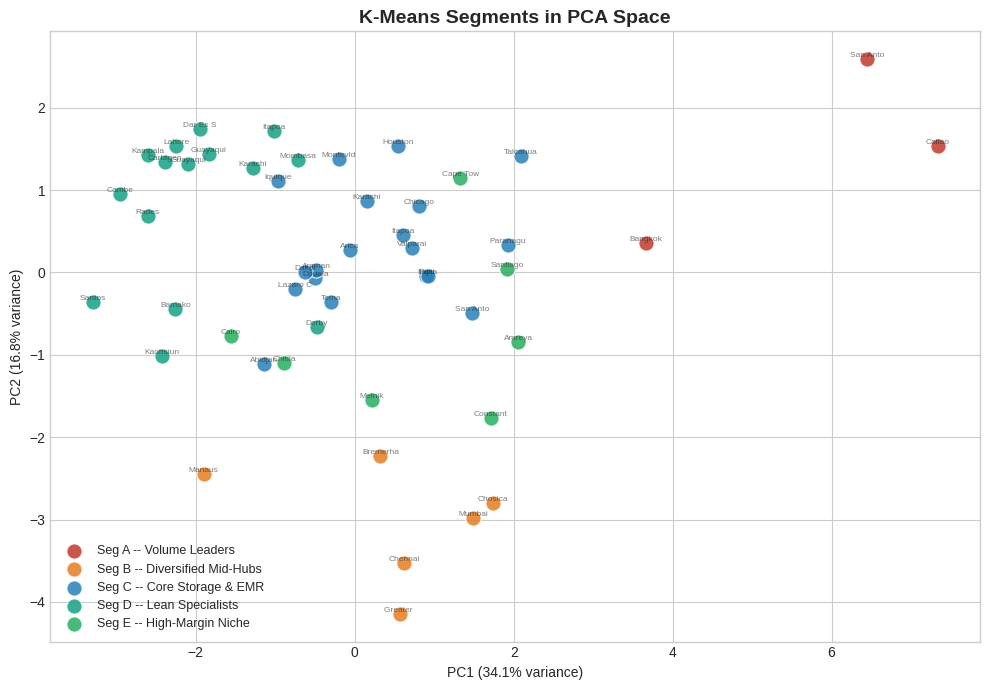

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]
var1, var2 = pca.explained_variance_ratio_
print(f"PCA: PC1={var1:.1%}  PC2={var2:.1%}  Total={var1+var2:.1%}")

fig, ax = plt.subplots(figsize=(10, 7))
for seg in sorted(df_cluster['Segment'].unique()):
    mask = df_cluster['Segment'] == seg
    ax.scatter(df_cluster.loc[mask,'PCA1'], df_cluster.loc[mask,'PCA2'],
               c=SEG_COLORS[seg], label=f'Seg {seg} -- {SEG_NAMES[seg]}',
               s=120, alpha=0.85, edgecolors='white', linewidth=0.8)
    for _, row in df_cluster[mask].iterrows():
        ax.annotate(row['City'][:8], (row['PCA1'], row['PCA2']),
                    fontsize=6, alpha=0.6, ha='center', va='bottom')
ax.set_xlabel(f'PC1 ({var1:.1%} variance)')
ax.set_ylabel(f'PC2 ({var2:.1%} variance)')
ax.set_title('K-Means Segments in PCA Space', fontsize=14, fontweight='bold')
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout(); plt.show()

## 7. Hierarchical Clustering Validation

K-Means distribution      : {'A': np.int64(3), 'B': np.int64(6), 'C': np.int64(19), 'D': np.int64(15), 'E': np.int64(7)}
Hierarchical distribution : {'A': np.int64(2), 'B': np.int64(4), 'C': np.int64(26), 'D': np.int64(13), 'E': np.int64(5)}
Overall agreement         : 39/50 (78.0%)
Threshold: >70% agreement confirms k=5 is structurally robust.

Border-case depots assigned differently (11):
  Manaus             Brazil             K-Means=B  Hier=E  Rev=$0.3M  Margin=58.7%
  Abidjan            Ivory Coast        K-Means=C  Hier=E  Rev=$5.1M  Margin=50.1%
  Santiago           Chile              K-Means=E  Hier=C  Rev=$6.0M  Margin=82.7%
  Melnik             Czech Republic     K-Means=E  Hier=C  Rev=$5.6M  Margin=62.2%
  Bremerhaven        Germany            K-Means=B  Hier=C  Rev=$12.3M  Margin=54.9%
  Amreya             Egypt              K-Means=E  Hier=C  Rev=$1.9M  Margin=78.1%
  Derby              United Kingdom     K-Means=D  Hier=C  Rev=$1.0M  Margin=75.3%
  Bamako             Mal

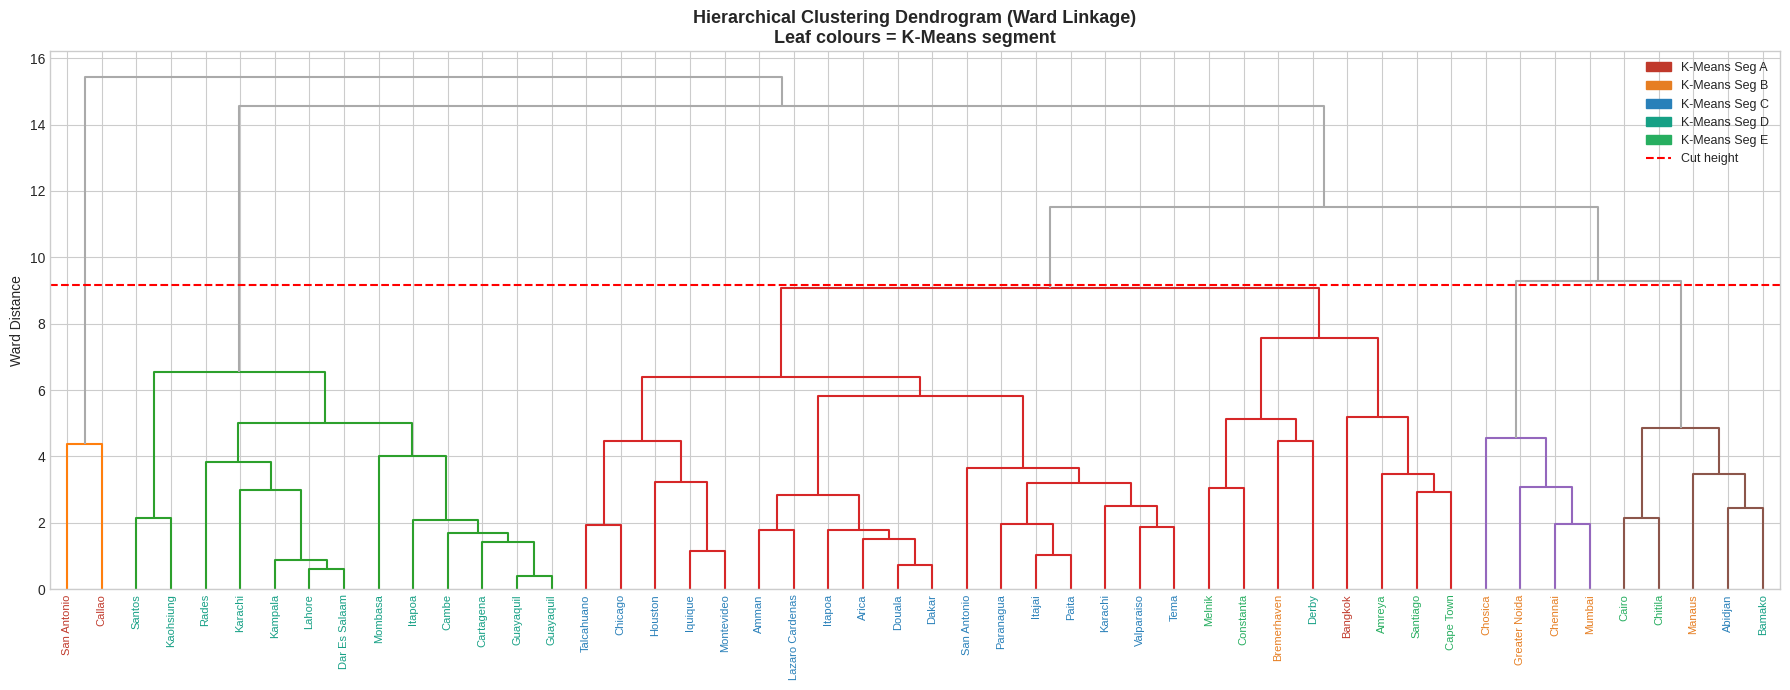

In [ ]:
Z = linkage(X_scaled, method='ward')
hier_labels = fcluster(Z, t=5, criterion='maxclust')
df_cluster['Hier_Cluster'] = hier_labels

hier_rev = (df_cluster.groupby('Hier_Cluster')['Revenue_Total']
             .mean().sort_values(ascending=False).index.tolist())
df_cluster['Hier_Segment'] = df_cluster['Hier_Cluster'].map(
    {c: lbl for c, lbl in zip(hier_rev, list('ABCDE'))})

agreement = (df_cluster['Segment'] == df_cluster['Hier_Segment']).mean()
n_agree   = (df_cluster['Segment'] == df_cluster['Hier_Segment']).sum()
print(f"K-Means distribution      : {dict(df_cluster['Segment'].value_counts().sort_index())}")
print(f"Hierarchical distribution : {dict(df_cluster['Hier_Segment'].value_counts().sort_index())}")
print(f"Overall agreement         : {n_agree}/{len(df_cluster)} ({agreement*100:.1f}%)")
print("Threshold: >70% agreement confirms k=5 is structurally robust.")
print()

diff = df_cluster[df_cluster['Segment'] != df_cluster['Hier_Segment']][
    ['City','Country','Segment','Hier_Segment','Revenue_3yr_avg','GP_Margin_2yr_avg']].copy()
if len(diff) > 0:
    print(f"Border-case depots assigned differently ({len(diff)}):")
    for _, row in diff.iterrows():
        print(f"  {row['City']:<18} {row['Country']:<18} K-Means={row['Segment']}  "
              f"Hier={row['Hier_Segment']}  Rev=${row['Revenue_3yr_avg']/1e6:.1f}M  "
              f"Margin={row['GP_Margin_2yr_avg']:.1f}%")

distances_sorted = sorted(Z[:, 2], reverse=True)
cut_height = (distances_sorted[3] + distances_sorted[4]) / 2

fig, ax = plt.subplots(figsize=(18, 7))
dend = dendrogram(Z, labels=df_cluster['City'].values, ax=ax,
                  leaf_rotation=90, leaf_font_size=8,
                  color_threshold=cut_height, above_threshold_color='#AAAAAA')
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5, label='Cut height -> k=5')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)\nLeaf colours = K-Means segment',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Ward Distance')
for lbl, leaf in zip(ax.get_xticklabels(), dend['leaves']):
    lbl.set_color(SEG_COLORS.get(df_cluster.loc[leaf,'Segment'], '#000000'))
patches = [mpatches.Patch(color=v, label=f'K-Means Seg {k}') for k, v in SEG_COLORS.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='red', linestyle='--', label='Cut height')],
          loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

## 8. Segment Profiles

In [ ]:
print("=" * 110)
print(f"  {'Seg':<4} {'Name':<22} {'N':>3}  {'Rev 3yr avg':>13}  "
      f"{'GP Margin 2yr':>14}  {'GP Margin 2024':>15}  {'Site m2':>9}  {'TEU':>6}  {'Prods':>6}")
print("=" * 110)
for seg in ['A','B','C','D','E']:
    s     = df_cluster[df_cluster['Segment'] == seg]
    valid = s[s['Revenue_2024'] > 0]
    print(f"  {seg}   {SEG_NAMES[seg]:<22} {len(s):>3}  "
          f"${s['Revenue_3yr_avg'].mean():>11,.0f}  "
          f"{valid['GP_Margin_2yr_avg'].mean():>13.1f}%  "
          f"{valid['GP_Margin_2024'].mean():>13.1f}%  "
          f"{s['Site_m'].mean():>8,.0f}  "
          f"{s['Max_TEU_Capacity'].mean():>5,.0f}  "
          f"{s['Product_Count'].mean():>5.1f}")

print()
print("Service mix per segment:")
bool_features = ['Has_EMR','Has_Empty_Storage','Has_Full_Storage','Has_Stuffing',
                 'Has_Reefer','Has_Accessories','Has_Container_Prep','Connected_Rail','Is_Bonded']
print(f"  {'Feature':<25}" + "".join(f"  {'Seg '+s:>10}" for s in 'ABCDE'))
print("  " + "-"*80)
for feat in bool_features:
    row = f"  {feat:<25}"
    for seg in ['A','B','C','D','E']:
        s = df_cluster[df_cluster['Segment']==seg]
        row += f"  {s[feat].sum()}/{len(s)} ({s[feat].mean()*100:.0f}%)"
    print(row)

print()
print("Depot listings:")
for seg in ['A','B','C','D','E']:
    s = df_cluster[df_cluster['Segment']==seg].sort_values('Revenue_2024', ascending=False)
    print(f"\n  Segment {seg} -- {SEG_NAMES[seg]}:")
    for _, row in s.iterrows():
        flag = '  [zero 2024 rev]' if row['Revenue_2024'] == 0 else ''
        print(f"    {row['Site_ID']:<12}  {row['City']}, {row['Country']}{flag}")

  Seg  Name                     N    Rev 3yr avg   GP Margin 2yr   GP Margin 2024    Site m2     TEU   Prods
  A   Volume Leaders           3  $ 42,186,777           52.0%           56.9%   156,667  13,667    7.0
  B   Diversified Mid-Hubs     6  $  7,133,202           48.3%           53.1%    63,083  2,997    3.7
  C   Core Storage & EMR      19  $  6,996,208           50.6%           53.5%    50,705  3,276    5.3
  D   Lean Specialists        15  $  4,492,926           55.5%           57.0%    22,294  1,596    2.8
  E   High-Margin Niche        7  $  4,048,408           68.3%           73.5%    36,829  3,513    5.6

Service mix per segment:
  Feature                         Seg A       Seg B       Seg C       Seg D       Seg E
  --------------------------------------------------------------------------------
  Has_EMR                    3/3 (100%)  1/6 (17%)  17/19 (89%)  13/15 (87%)  5/7 (71%)
  Has_Empty_Storage          3/3 (100%)  0/6 (0%)  19/19 (100%)  13/15 (87%)  7/7 (100%)
 

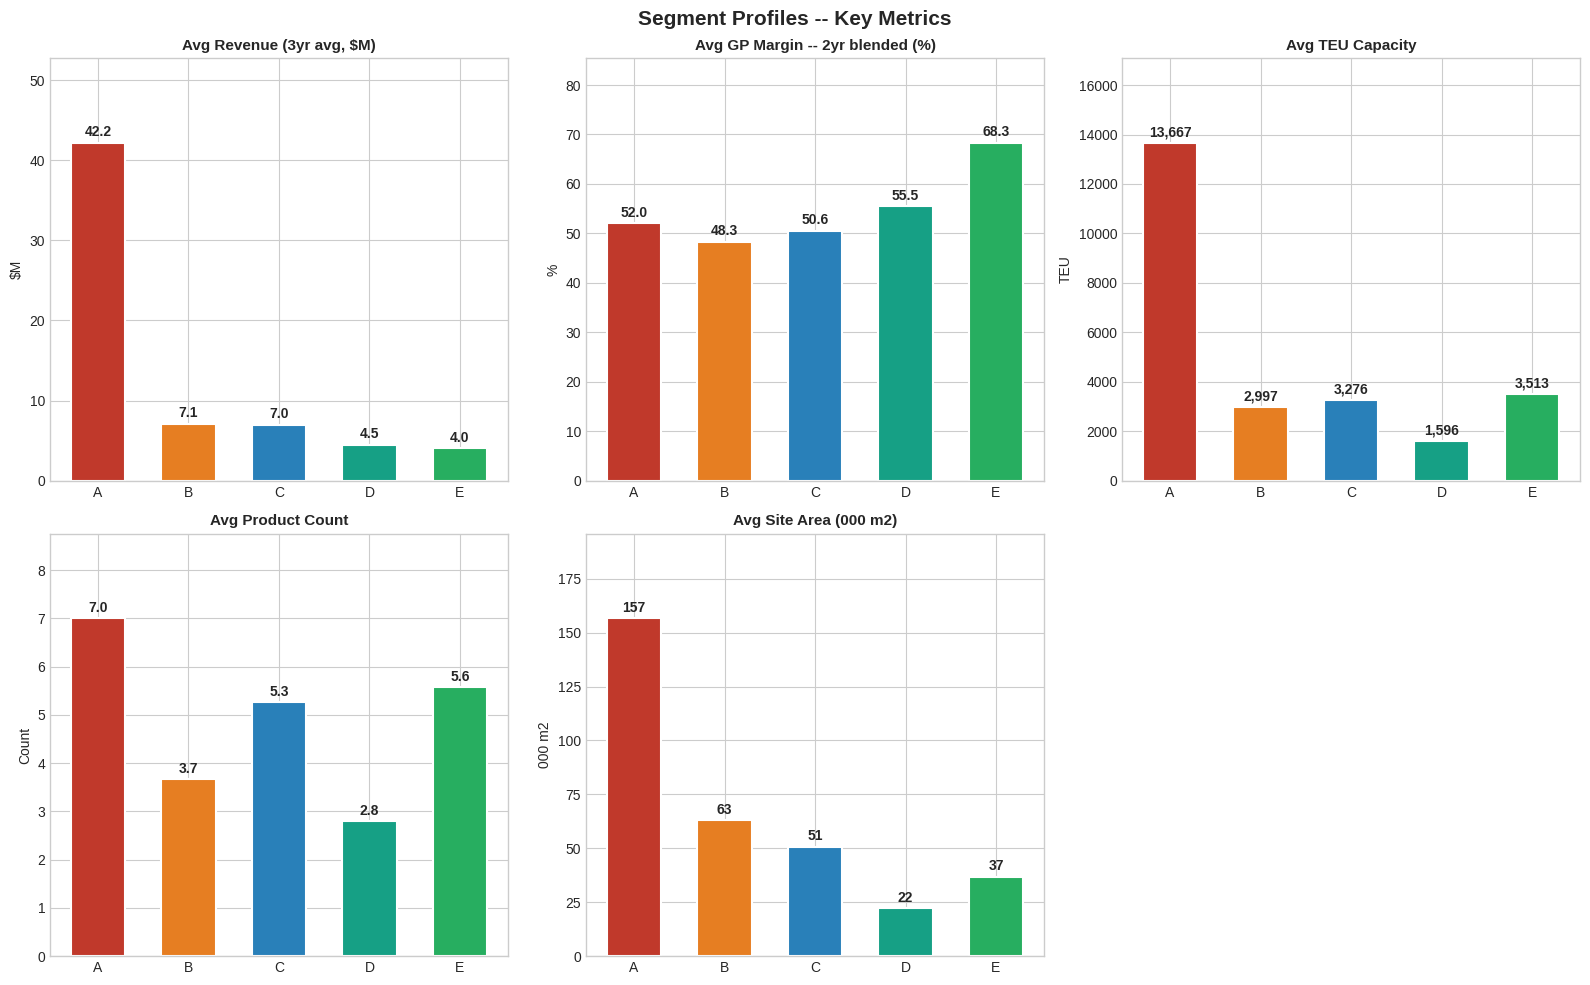

In [ ]:
segs     = ['A','B','C','D','E']
seg_rev  = [df_cluster[df_cluster['Segment']==s]['Revenue_3yr_avg'].mean()/1e6 for s in segs]
seg_marg = [df_cluster[(df_cluster['Segment']==s)&(df_cluster['Revenue_2024']>0)]['GP_Margin_2yr_avg'].mean() for s in segs]
seg_teu  = [df_cluster[df_cluster['Segment']==s]['Max_TEU_Capacity'].mean() for s in segs]
seg_prod = [df_cluster[df_cluster['Segment']==s]['Product_Count'].mean() for s in segs]
seg_site = [df_cluster[df_cluster['Segment']==s]['Site_m'].mean()/1e3 for s in segs]
colors   = [SEG_COLORS[s] for s in segs]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Segment Profiles -- Key Metrics', fontsize=15, fontweight='bold')
for ax, values, title, ylabel, fmt in zip(
    axes.flat,
    [seg_rev, seg_marg, seg_teu, seg_prod, seg_site],
    ['Avg Revenue (3yr avg, $M)', 'Avg GP Margin -- 2yr blended (%)',
     'Avg TEU Capacity', 'Avg Product Count', 'Avg Site Area (000 m2)'],
    ['$M', '%', 'TEU', 'Count', '000 m2'],
    ['.1f', '.1f', ',.0f', '.1f', '.0f']
):
    bars = ax.bar(segs, values, color=colors, width=0.6, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=11, fontweight='bold'); ax.set_ylabel(ylabel)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values)*0.01,
                f'{val:{fmt}}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(values)*1.25)
axes.flat[-1].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Profitability Driver Analysis
### 9a. Spearman Correlation (baseline)

In [ ]:
DRIVER_FEATURES = [
    'Site_m', 'Max_TEU_Capacity', 'Product_Count',
    'Has_EMR', 'Has_Empty_Storage', 'Has_Full_Storage',
    'Has_Stuffing', 'Has_Reefer', 'Has_Accessories', 'Has_Container_Prep',
    'Connected_Rail', 'Is_Bonded', 'Revenue_per_sqm'
]

results = []
for target in ['Revenue_2024', 'GP_Margin_2024']:
    for driver in DRIVER_FEATURES:
        valid = df_cluster[[driver, target]].dropna()
        valid = valid[np.isfinite(valid[target])]
        if len(valid) > 3:
            r, p = spearmanr(valid[driver], valid[target])
            results.append({'Target':target,'Driver':driver,'Spearman_r':r,
                            'p_value':p,'Significant':p<0.05})
corr_df = pd.DataFrame(results)

for target in ['Revenue_2024', 'GP_Margin_2024']:
    print(f"\nTOP DRIVERS -- {target}:")
    sub = corr_df[corr_df['Target']==target].sort_values('Spearman_r', key=abs, ascending=False)
    print(sub[['Driver','Spearman_r','p_value','Significant']].head(8).to_string(index=False))
print()
print("Note: Many GP margin correlations are not statistically significant (p>0.05).")
print("This is expected with n=49 and nonlinear relationships. Use RF/SHAP for importance.")


TOP DRIVERS -- Revenue_2024:
            Driver  Spearman_r  p_value  Significant
   Revenue_per_sqm        0.59     0.00         True
Has_Container_Prep        0.46     0.00         True
            Site_m        0.46     0.00         True
  Max_TEU_Capacity        0.43     0.00         True
     Product_Count        0.37     0.01         True
           Has_EMR        0.28     0.05         True
      Has_Stuffing        0.20     0.17        False
        Has_Reefer        0.14     0.33        False

TOP DRIVERS -- GP_Margin_2024:
           Driver  Spearman_r  p_value  Significant
  Has_Accessories        0.34     0.02         True
Has_Empty_Storage        0.24     0.10        False
  Revenue_per_sqm       -0.23     0.12        False
     Has_Stuffing       -0.22     0.13        False
 Max_TEU_Capacity        0.18     0.22        False
          Has_EMR       -0.16     0.27        False
   Connected_Rail        0.12     0.42        False
 Has_Full_Storage        0.11     0.47       

### 9b. Random Forest + SHAP -- Global GP Margin Drivers

In [ ]:
# Excluded from features:
#   GP_Margin_Total  -- circular (predicting margin using margin)
#   Revenue_Total    -- outcome variable, not an actionable lever
#   Max_FFE_Capacity -- highly collinear with Max_TEU_Capacity
# Target: GP_Margin_2024 (single-year, avoids leaking 2025 data)
# Manaus (BR002) excluded: Revenue_2024=0 -> GP_Margin_2024=NaN

RF_FEATURES = [
    'Site_m', 'Max_TEU_Capacity',
    'Product_Count', 'Has_EMR', 'Has_Empty_Storage', 'Has_Full_Storage',
    'Has_Stuffing', 'Has_Reefer', 'Connected_Truck', 'Connected_Rail', 'Is_Bonded'
]

train_mask = df_cluster['Revenue_2024'] > 0
X_margin   = df_cluster.loc[train_mask, RF_FEATURES].copy()
y_margin   = df_cluster.loc[train_mask, 'GP_Margin_2024'].copy()
print(f"Training: {train_mask.sum()} depots  ({(~train_mask).sum()} excluded -- zero revenue)")

rf_margin = RandomForestRegressor(n_estimators=200, max_depth=8,
                                   min_samples_split=5, min_samples_leaf=2,
                                   random_state=42, n_jobs=-1)
rf_margin.fit(X_margin, y_margin)
r2_train  = r2_score(y_margin, rf_margin.predict(X_margin))
cv_scores = cross_val_score(rf_margin, X_margin, y_margin, cv=5, scoring='r2')
print(f"R2 (train)    : {r2_train:.3f}")
print(f"R2 (5-fold CV): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print()
print("WARNING: CV R2 is negative -- model overfits on n=49.")
print("Feature importance is directionally useful but not predictively reliable.")

rf_importance = pd.DataFrame({
    'Feature':      RF_FEATURES,
    'Importance_%': rf_margin.feature_importances_ * 100
}).sort_values('Importance_%', ascending=False).reset_index(drop=True)

print("\nRF Feature Importance:")
for i, row in rf_importance.iterrows():
    print(f"  {i+1:2d}. {row['Feature']:<25} {row['Importance_%']:>6.2f}%")

print("\nComputing SHAP values...")
explainer   = shap.TreeExplainer(rf_margin)
shap_values = explainer.shap_values(X_margin)

shap_importance = pd.DataFrame({
    'Feature':       RF_FEATURES,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0),
    'Mean_SHAP':     shap_values.mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
shap_importance['SHAP_Pct'] = shap_importance['Mean_Abs_SHAP'] / shap_importance['Mean_Abs_SHAP'].sum() * 100

print("\nSHAP Feature Importance (GP Margin drivers):")
print(f"  {'Rank':<5} {'Feature':<25} {'SHAP %':>8}  Direction")
print("  " + "-"*55)
for i, row in shap_importance.iterrows():
    direction = "increases margin" if row['Mean_SHAP'] > 0 else "decreases margin"
    print(f"  {i+1:<5} {row['Feature']:<25} {row['SHAP_Pct']:>7.1f}%  {direction}")

Training: 49 depots  (1 excluded -- zero revenue)
R2 (train)    : 0.699
R2 (5-fold CV): -0.690 +/- 0.824

Feature importance is directionally useful but not predictively reliable.

RF Feature Importance:
   1. Site_m                     47.68%
   2. Max_TEU_Capacity           28.46%
   3. Product_Count               8.18%
   4. Has_Stuffing                5.09%
   5. Has_EMR                     3.24%
   6. Connected_Rail              2.23%
   7. Has_Reefer                  1.97%
   8. Has_Empty_Storage           1.56%
   9. Has_Full_Storage            1.29%
  10. Is_Bonded                   0.30%
  11. Connected_Truck             0.00%

Computing SHAP values...

SHAP Feature Importance (GP Margin drivers):
  Rank  Feature                     SHAP %  Direction
  -------------------------------------------------------
  1     Site_m                       34.5%  increases margin
  2     Max_TEU_Capacity             33.5%  decreases margin
  3     Has_Stuffing                 11.2%  increa

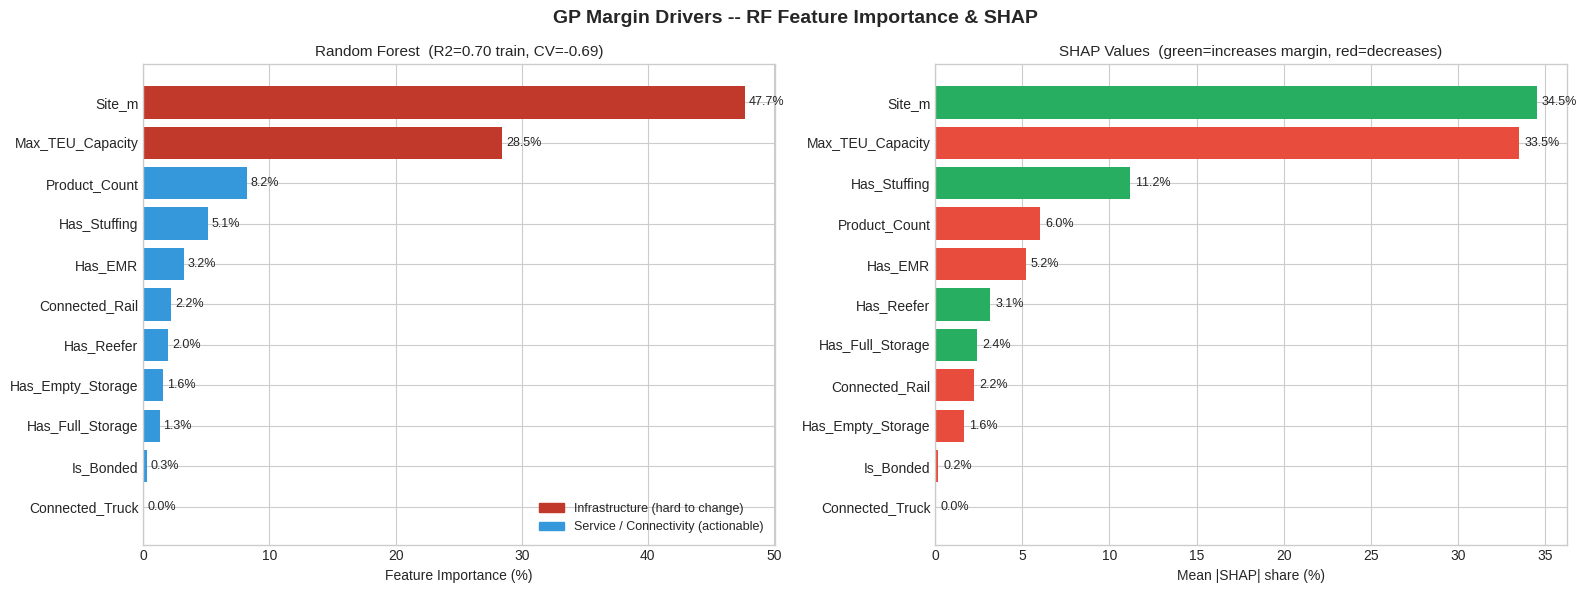

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GP Margin Drivers -- RF Feature Importance & SHAP', fontsize=14, fontweight='bold')

infra_feats = {'Site_m','Max_TEU_Capacity'}
rf_col = ['#C0392B' if f in infra_feats else '#3498DB' for f in rf_importance['Feature']]
axes[0].barh(rf_importance['Feature'][::-1], rf_importance['Importance_%'][::-1], color=rf_col[::-1])
axes[0].set_xlabel('Feature Importance (%)')
axes[0].set_title(f'Random Forest  (R2={r2_train:.2f} train, CV={cv_scores.mean():.2f})', fontsize=11)
for i, (val, _) in enumerate(zip(rf_importance['Importance_%'][::-1], rf_importance['Feature'][::-1])):
    axes[0].text(val+0.3, i, f'{val:.1f}%', va='center', fontsize=9)

shap_col = ['#27AE60' if v > 0 else '#E74C3C' for v in shap_importance['Mean_SHAP']]
axes[1].barh(shap_importance['Feature'][::-1], shap_importance['SHAP_Pct'][::-1], color=shap_col[::-1])
axes[1].set_xlabel('Mean |SHAP| share (%)')
axes[1].set_title('SHAP Values  (green=increases margin, red=decreases)', fontsize=11)
for i, val in enumerate(shap_importance['SHAP_Pct'][::-1]):
    axes[1].text(val+0.3, i, f'{val:.1f}%', va='center', fontsize=9)

infra_patch  = mpatches.Patch(color='#C0392B', label='Infrastructure (hard to change)')
service_patch= mpatches.Patch(color='#3498DB', label='Service / Connectivity (actionable)')
axes[0].legend(handles=[infra_patch, service_patch], loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### 9c. OLS / Ridge / Lasso regression

In [ ]:
feat_scaler = StandardScaler()
X_reg = feat_scaler.fit_transform(df_cluster.loc[train_mask, RF_FEATURES])
y_reg = df_cluster.loc[train_mask, 'GP_Margin_2024'].values

models_reg = {'OLS': LinearRegression(), 'Ridge': Ridge(alpha=10, max_iter=10000),
              'Lasso': Lasso(alpha=2, max_iter=10000)}
reg_results = {}
print(f"{'Model':<8} {'R2 train':>10} {'R2 CV mean':>12} {'R2 CV std':>10}")
print("-" * 45)
for name, model in models_reg.items():
    model.fit(X_reg, y_reg)
    r2_tr = r2_score(y_reg, model.predict(X_reg))
    cv    = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')
    reg_results[name] = {'model':model,'r2_train':r2_tr,'cv':cv,
                          'coefs': pd.Series(model.coef_, index=RF_FEATURES)}
    print(f"  {name:<6} {r2_tr:>10.3f} {cv.mean():>12.3f} {cv.std():>10.3f}")

print()
coef_df = pd.DataFrame({n: res['coefs'] for n, res in reg_results.items()})
print("Standardised coefficients (pp GP margin per 1 SD change):")
print(coef_df.round(2).to_string())
print()
print("Features where all 3 models agree on direction:")
for feat in RF_FEATURES:
    signs = [np.sign(reg_results[m]['coefs'][feat]) for m in models_reg]
    if len(set(signs)) == 1:
        direction = "increases margin" if signs[0] > 0 else "decreases margin"
        rf_imp = rf_importance.set_index('Feature').loc[feat,'Importance_%']
        print(f"  {feat:<25}  {direction}  (RF: {rf_imp:.1f}%)")

Model      R2 train   R2 CV mean  R2 CV std
---------------------------------------------
  OLS         0.310       -0.734      0.543
  Ridge       0.286       -0.451      0.409
  Lasso       0.196       -0.605      0.413

Standardised coefficients (pp GP margin per 1 SD change):
                    OLS  Ridge  Lasso
Site_m            -4.79  -1.92  -0.00
Max_TEU_Capacity   7.81   4.60   2.12
Product_Count      0.41   0.42   0.00
Has_EMR           -4.72  -3.97  -2.97
Has_Empty_Storage  5.67   4.28   2.77
Has_Full_Storage   4.04   2.55   0.29
Has_Stuffing      -6.61  -5.13  -3.09
Has_Reefer        -2.73  -1.72  -0.00
Connected_Truck    0.00   0.00   0.00
Connected_Rail     1.08   1.65   0.88
Is_Bonded          3.97   1.84   0.00

Features where all 3 models agree on direction:
  Max_TEU_Capacity           increases margin  (RF: 28.5%)
  Has_EMR                    decreases margin  (RF: 3.2%)
  Has_Empty_Storage          increases margin  (RF: 1.6%)
  Has_Full_Storage           increases 

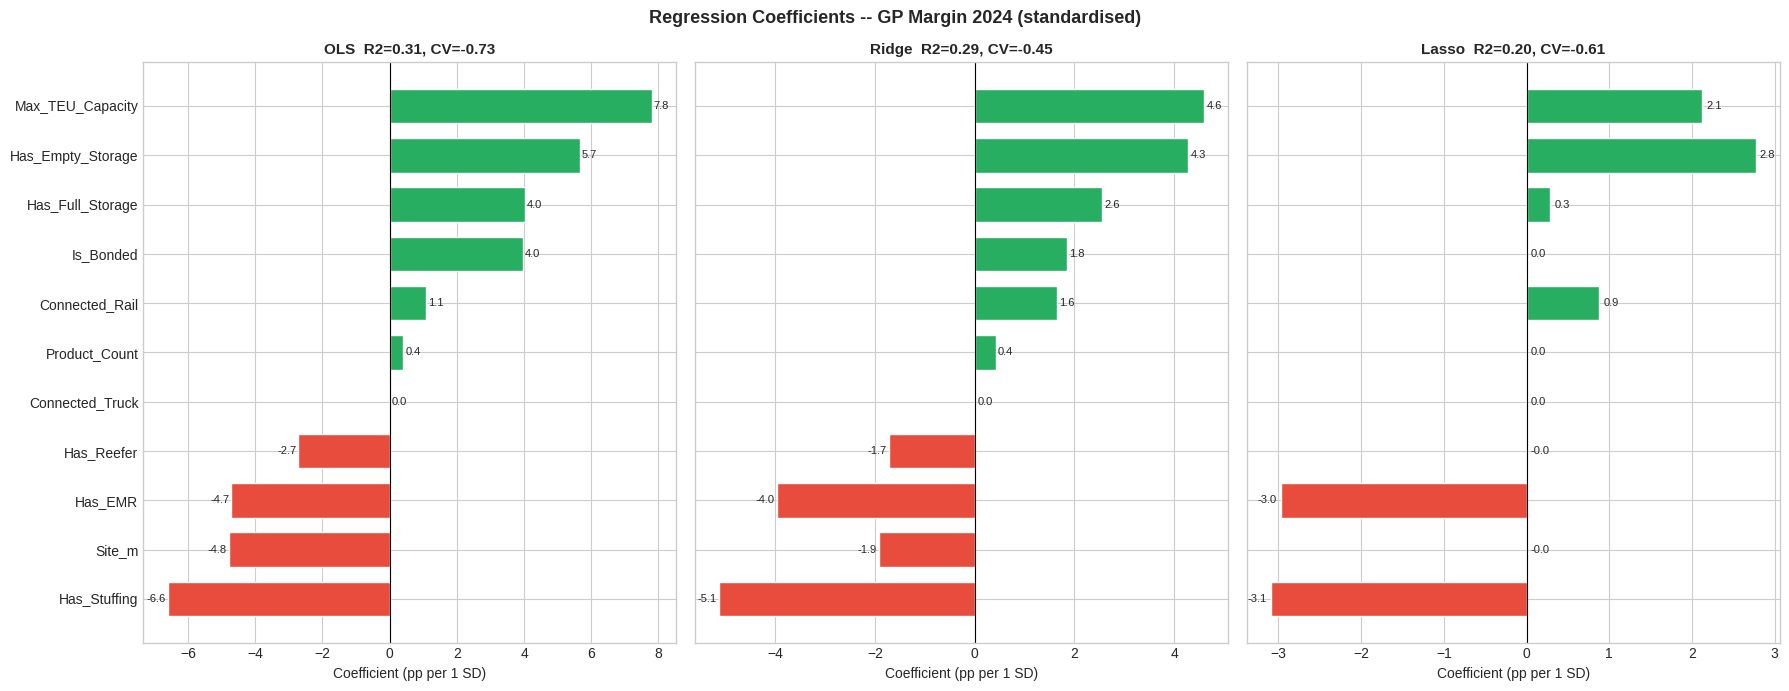

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle('Regression Coefficients -- GP Margin 2024 (standardised)',
             fontsize=13, fontweight='bold')
for ax, name in zip(axes, ['OLS','Ridge','Lasso']):
    coefs  = reg_results[name]['coefs'].sort_values()
    colors = ['#27AE60' if v > 0 else '#E74C3C' for v in coefs.values]
    bars   = ax.barh(coefs.index, coefs.values, color=colors, edgecolor='white', height=0.7)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'{name}  R2={reg_results[name]["r2_train"]:.2f}, CV={reg_results[name]["cv"].mean():.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient (pp per 1 SD)')
    for bar, val in zip(bars, coefs.values):
        ha, off = ('left', 0.05) if val >= 0 else ('right', -0.05)
        ax.text(val+off, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', ha=ha, fontsize=8)
plt.tight_layout(); plt.show()

### 9d. Within-Segment Ridge Regression

In [ ]:
print("WITHIN-SEGMENT RIDGE REGRESSION")
print("Directional only -- small n per segment.")
print("=" * 65)
segment_reg = {}
for seg in ['A','B','C','D','E']:
    seg_data = df_cluster[(df_cluster['Segment']==seg) & (df_cluster['Revenue_2024']>0)]
    print(f"\nSegment {seg} -- {SEG_NAMES[seg]} ({len(seg_data)} depots)")
    print("-" * 50)
    if len(seg_data) < 5:
        print("  < 5 depots -- insufficient for regression. Skipped.")
        continue
    X_s = feat_scaler.fit_transform(seg_data[RF_FEATURES])
    y_s = seg_data['GP_Margin_2024'].values
    m   = Ridge(alpha=5).fit(X_s, y_s)
    r2s = r2_score(y_s, m.predict(X_s))
    coefs_s = pd.Series(m.coef_, index=RF_FEATURES).sort_values(key=abs, ascending=False)
    print(f"  R2 (train): {r2s:.3f}  [directional only, n={len(seg_data)}]")
    for feat, coef in coefs_s.head(5).items():
        print(f"  {feat:<25} {coef:>8.2f}  {'up' if coef > 0 else 'down'}")
    segment_reg[seg] = {'r2': r2s, 'coefs': coefs_s}

WITHIN-SEGMENT RIDGE REGRESSION
Directional only -- small n per segment.

Segment A -- Volume Leaders (3 depots)
--------------------------------------------------
  < 5 depots -- insufficient for regression. Skipped.

Segment B -- Diversified Mid-Hubs (5 depots)
--------------------------------------------------
  R2 (train): 0.805  [directional only, n=5]
  Has_Reefer                   -2.90  down
  Product_Count                 2.37  up
  Connected_Rail               -2.04  down
  Max_TEU_Capacity              2.04  up
  Has_EMR                       1.92  up

Segment C -- Core Storage & EMR (19 depots)
--------------------------------------------------
  R2 (train): 0.243  [directional only, n=19]
  Max_TEU_Capacity              3.68  up
  Has_Reefer                   -3.45  down
  Has_EMR                      -2.49  down
  Has_Stuffing                 -2.48  down
  Site_m                       -1.40  down

Segment D -- Lean Specialists (15 depots)
---------------------------------

## 10. Migration Pathway Analysis

In [ ]:
from sklearn.linear_model import LinearRegression as LR_mig

print("OLS: Revenue_3yr_avg ~ Product_Count  (within each source segment)")
print("=" * 65)
migration_results = {}
for seg in ['B','C','D','E']:
    s = df_cluster[(df_cluster['Segment']==seg) & (df_cluster['Revenue_3yr_avg']>0)]
    if len(s) < 3:
        continue
    m     = LR_mig().fit(s[['Product_Count']].values, s['Revenue_3yr_avg'].values)
    r2    = r2_score(s['Revenue_3yr_avg'].values, m.predict(s[['Product_Count']].values))
    uplift = m.coef_[0]
    migration_results[seg] = {'uplift': uplift, 'r2': r2, 'n': len(s)}
    print(f"  Seg {seg} -- {SEG_NAMES[seg]:<22}: "
          f"+${uplift/1e6:.1f}M per product  (R2={r2:.2f}, n={len(s)})")

print()
for seg in ['A','B','C','D','E']:
    s     = df_cluster[df_cluster['Segment']==seg]
    valid = s[s['Revenue_2024']>0]
    print(f"  Seg {seg}: N={len(s):2d}  Rev_3yr=${s['Revenue_3yr_avg'].mean()/1e6:.1f}M  "
          f"Margin_2yr={valid['GP_Margin_2yr_avg'].mean():.1f}%  "
          f"TEU={s['Max_TEU_Capacity'].mean():.0f}  Site={s['Site_m'].mean():.0f}m2")

OLS: Revenue_3yr_avg ~ Product_Count  (within each source segment)
  Seg B -- Diversified Mid-Hubs  : +$4.7M per product  (R2=0.35, n=6)
  Seg C -- Core Storage & EMR    : +$-0.9M per product  (R2=0.03, n=19)
  Seg D -- Lean Specialists      : +$-0.2M per product  (R2=0.00, n=15)
  Seg E -- High-Margin Niche     : +$2.6M per product  (R2=0.87, n=7)

  Seg A: N= 3  Rev_3yr=$42.2M  Margin_2yr=52.0%  TEU=13667  Site=156667m2
  Seg B: N= 6  Rev_3yr=$7.1M  Margin_2yr=48.3%  TEU=2997  Site=63083m2
  Seg C: N=19  Rev_3yr=$7.0M  Margin_2yr=50.6%  TEU=3276  Site=50705m2
  Seg D: N=15  Rev_3yr=$4.5M  Margin_2yr=55.5%  TEU=1596  Site=22294m2
  Seg E: N= 7  Rev_3yr=$4.0M  Margin_2yr=68.3%  TEU=3513  Site=36829m2


In [ ]:
def seg_stat(seg, col):
    return df_cluster[df_cluster['Segment']==seg][col].mean()

print("=" * 75)
print("SEGMENT MIGRATION PATHWAYS")
print("=" * 75)

pathways = [
    {
        'from_to': 'D -> C',
        'label':   'Lean Specialists -> Core Storage & EMR',
        'headline': (f"15 depots  "
                     f"+${migration_results.get('D',{}).get('uplift',1e6)/1e6:.1f}M per product added"),
        'actions': [
            f"Add Empty Container Storage (Seg C: 100%, Seg D: {seg_stat('D','Has_Empty_Storage')*100:.0f}%) -- highest-return, lowest cost",
            f"Add Full Container Storage  (Seg C: 100%, Seg D: {seg_stat('D','Has_Full_Storage')*100:.0f}%)",
            "Increase EMR coverage from 87% to 90%+ to anchor revenue base",
        ]
    },
    {
        'from_to': 'C -> A',
        'label':   'Core Storage & EMR -> Volume Leaders',
        'headline': (f"19 depots  ~6x revenue upside  "
                     f"+${migration_results.get('C',{}).get('uplift',1.2e6)/1e6:.1f}M per product added"),
        'actions': [
            f"Expand site area toward 80,000-160,000 m2 (Seg C avg: {seg_stat('C','Site_m'):,.0f} m2)",
            f"TEU >8,000 (Seg C avg: {seg_stat('C','Max_TEU_Capacity'):,.0f}, Seg A avg: {seg_stat('A','Max_TEU_Capacity'):,.0f})",
            "Add Stuffing and Reefer -- top-3 service drivers in Seg A",
        ]
    },
    {
        'from_to': 'B -> A',
        'label':   'Diversified Mid-Hubs -> Volume Leaders',
        'headline': (f"6 depots  ~6x revenue upside  "
                     f"+${migration_results.get('B',{}).get('uplift',4.7e6)/1e6:.1f}M per product added"),
        'actions': [
            f"Expand site area >80,000 m2 (Seg B avg: {seg_stat('B','Site_m'):,.0f} m2)",
            f"Invest in rail connectivity (Seg B: {seg_stat('B','Connected_Rail')*100:.0f}%, Seg A: {seg_stat('A','Connected_Rail')*100:.0f}%)",
            f"Achieve TEU >5,000 (Seg B avg: {seg_stat('B','Max_TEU_Capacity'):,.0f}, Seg A avg: {seg_stat('A','Max_TEU_Capacity'):,.0f})",
        ]
    },
    {
        'from_to': 'E -> A',
        'label':   'High-Margin Niche -> Volume Leaders',
        'headline': (f"7 depots  ~10x revenue upside  "
                     f"+${migration_results.get('E',{}).get('uplift',2.6e6)/1e6:.1f}M per product added  "
                     f"(R2={migration_results.get('E',{}).get('r2',0.87):.2f})"),
        'actions': [
            "Audit captive customer contracts before scaling -- premium mix drives the margin premium",
            f"Deploy Container Prep and Accessories (Seg E: {seg_stat('E','Has_Container_Prep')*100:.0f}% and {seg_stat('E','Has_Accessories')*100:.0f}%)",
            f"Target bonded yard certification for eligible sites (Seg E: {seg_stat('E','Is_Bonded')*100:.0f}%)",
        ]
    },
]

for p in pathways:
    sf = df_cluster[df_cluster['Segment']==p['from_to'][0]]
    st = df_cluster[df_cluster['Segment']==p['from_to'][-1]]
    vm = sf[sf['Revenue_2024']>0]['GP_Margin_2yr_avg'].mean()
    vt = st[st['Revenue_2024']>0]['GP_Margin_2yr_avg'].mean()
    print(f"\n{'─'*65}")
    print(f"  {p['from_to']}  |  {p['label']}")
    print(f"  {p['headline']}")
    print(f"  (Source margin: {vm:.1f}%  ->  Target margin: {vt:.1f}%)")
    for a in p['actions']:
        print(f"    - {a}")

SEGMENT MIGRATION PATHWAYS

─────────────────────────────────────────────────────────────────
  D -> C  |  Lean Specialists -> Core Storage & EMR
  15 depots  +$-0.2M per product added
  (Source margin: 55.5%  ->  Target margin: 50.6%)
    - Add Empty Container Storage (Seg C: 100%, Seg D: 87%) -- highest-return, lowest cost
    - Add Full Container Storage  (Seg C: 100%, Seg D: 7%)
    - Increase EMR coverage from 87% to 90%+ to anchor revenue base

─────────────────────────────────────────────────────────────────
  C -> A  |  Core Storage & EMR -> Volume Leaders
  19 depots  ~6x revenue upside  +$-0.9M per product added
  (Source margin: 50.6%  ->  Target margin: 52.0%)
    - Expand site area toward 80,000-160,000 m2 (Seg C avg: 50,705 m2)
    - TEU >8,000 (Seg C avg: 3,276, Seg A avg: 13,667)
    - Add Stuffing and Reefer -- top-3 service drivers in Seg A

─────────────────────────────────────────────────────────────────
  B -> A  |  Diversified Mid-Hubs -> Volume Leaders
  6 depots

## 11. Key Findings & Strategic Recommendations

In [ ]:
valid_a = df_cluster[(df_cluster['Segment']=='A') & (df_cluster['Revenue_2024']>0)]
valid_e = df_cluster[(df_cluster['Segment']=='E') & (df_cluster['Revenue_2024']>0)]
seg_a   = df_cluster[df_cluster['Segment']=='A']
seg_e   = df_cluster[df_cluster['Segment']=='E']

total_2024    = df_cluster['Revenue_2024'].sum()
seg_a_rev24   = seg_a['Revenue_2024'].sum()
margin_gap    = valid_e['GP_Margin_2yr_avg'].mean() / valid_a['GP_Margin_2yr_avg'].mean()
top2_shap_pct = shap_importance.head(2)['SHAP_Pct'].sum()

print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)
print()
print("1. SCALE != MARGIN")
print(f"   Seg E: {valid_e['GP_Margin_2yr_avg'].mean():.1f}% GP margin on ${seg_e['Revenue_3yr_avg'].mean()/1e6:.1f}M avg revenue")
print(f"   Seg A: {valid_a['GP_Margin_2yr_avg'].mean():.1f}% GP margin on ${seg_a['Revenue_3yr_avg'].mean()/1e6:.1f}M avg revenue")
print(f"   Margin gap: {margin_gap:.2f}x  Rail, bonded yard, and premium mix drive Seg E's premium.")
print()
print("2. PHYSICAL INFRASTRUCTURE DOMINATES")
print(f"   {top2_shap_pct:.0f}% of GP margin variance (SHAP) from just 2 features:")
print(f"   #1 {shap_importance.iloc[0]['Feature']} ({shap_importance.iloc[0]['SHAP_Pct']:.1f}%)")
print(f"   #2 {shap_importance.iloc[1]['Feature']} ({shap_importance.iloc[1]['SHAP_Pct']:.1f}%)")
print(f"   These are long-horizon CapEx decisions.")
print()
print("3. CONCENTRATION RISK")
print(f"   {len(seg_a)} Seg A depots = {seg_a_rev24/total_2024*100:.1f}% of 2024 network revenue.")
print(f"   Underperformance at any single Seg A depot has outsized network impact.")
print()
print("4. C->A IS THE LARGEST SINGLE OPPORTUNITY")
print(f"   19 Seg C depots with ~6x revenue upside. Stuffing + Reefer are highest-ROI")
print(f"   service additions; physical infrastructure is the long-term enabler.")
print()
print("5. EMR + EMPTY STORAGE = NEAR-TERM WINS")
print(f"   Adding these to Seg D depots requires minimal CapEx with solid margin uplift.")
print()
print("=" * 70)
print("STRATEGIC RECOMMENDATIONS")
print("=" * 70)
print()
print(f"1. PRIORITISE SEG C PRODUCT EXPANSION (19 depots)")
print(f"   Add Stuffing and Reefer. $500K-$1M CapEx could migrate 6 depots to Seg B")
print(f"   within 18-24 months. Estimated incremental revenue: $12-18M. Target: C->A by 2027.")
print()
print(f"2. SCALE SEG B WITH RAIL + PORT ADJACENCY (6 depots)")
print(f"   Primary gap: TEU ({seg_stat('B','Max_TEU_Capacity'):,.0f} vs {seg_stat('A','Max_TEU_Capacity'):,.0f} Seg A avg).")
print(f"   3 depots targeting >5,000 TEU could unlock $60-90M additional revenue. Target: B->A by 2028.")
print()
print(f"3. REPLICATE SEG E MARGIN MODEL ACROSS NETWORK")
print(f"   Bonded yard + Container Prep + premium accessories drive the margin premium.")
print(f"   Certifying 5-8 Seg C/D depots could raise network avg margin to 50%+.")
print()
print(f"4. SEG D -- TWO PATHS (15 depots)")
print(f"   (a) Add EMR + Empty Storage -> migrate to Seg C (7 depots eligible, low CapEx)")
print(f"   (b) Deepen via Container Prep + Accessories -> maximise margin in-place (8 depots)")

KEY FINDINGS

1. SCALE != MARGIN
   Seg E: 68.3% GP margin on $4.0M avg revenue
   Seg A: 52.0% GP margin on $42.2M avg revenue
   Margin gap: 1.31x  Rail, bonded yard, and premium mix drive Seg E's premium.

2. PHYSICAL INFRASTRUCTURE DOMINATES
   68% of GP margin variance (SHAP) from just 2 features:
   #1 Site_m (34.5%)
   #2 Max_TEU_Capacity (33.5%)
   These are long-horizon CapEx decisions.

3. CONCENTRATION RISK
   3 Seg A depots = 27.5% of 2024 network revenue.
   Underperformance at any single Seg A depot has outsized network impact.

4. C->A IS THE LARGEST SINGLE OPPORTUNITY
   19 Seg C depots with ~6x revenue upside. Stuffing + Reefer are highest-ROI
   service additions; physical infrastructure is the long-term enabler.

5. EMR + EMPTY STORAGE = NEAR-TERM WINS
   Adding these to Seg D depots requires minimal CapEx with solid margin uplift.

STRATEGIC RECOMMENDATIONS

1. PRIORITISE SEG C PRODUCT EXPANSION (19 depots)
   Add Stuffing and Reefer. $500K-$1M CapEx could migrate 6

## 12. Export Results

In [ ]:
export_cols = [
    'Site_ID','Site_Name','Region','Area','Country','City','Operation_Type',
    'Segment','Cluster',
    'Revenue_2023','Revenue_2024','Revenue_2025','Revenue_Total','Revenue_3yr_avg','YoY_Growth_Pct',
    'GP_2024','GP_2025','GP_Total',
    'GP_Margin_2024','GP_Margin_2025','GP_Margin_2yr_avg',
    'Site_m','Max_TEU_Capacity','Max_FFE_Capacity',
    'Product_Count','Has_EMR','Has_Empty_Storage','Has_Full_Storage',
    'Has_Stuffing','Has_Reefer','Has_Accessories','Has_Container_Prep',
    'Connected_Rail','Connected_Truck','Is_Bonded',
    'Revenue_per_sqm','PCA1','PCA2'
]
export_cols = [c for c in export_cols if c in df_cluster.columns]
df_cluster[export_cols].to_csv('Depot_Segmentation_Results.csv', index=False)

df_cluster.groupby('Segment').agg(
    N=('Site_ID','count'),
    Rev_3yr_avg=('Revenue_3yr_avg','mean'),
    GP_Margin_2yr=('GP_Margin_2yr_avg','mean'),
    Site_m_avg=('Site_m','mean'),
    TEU_avg=('Max_TEU_Capacity','mean'),
    Product_Count_avg=('Product_Count','mean'),
).round(1).to_csv('Segment_Summary.csv')

rf_importance.to_csv('RF_Feature_Importance.csv', index=False)
shap_importance.to_csv('SHAP_Importance.csv', index=False)
corr_df.to_csv('Driver_Correlations.csv', index=False)

print("Output files written:")
print("  Depot_Segmentation_Results.csv  -- all 50 depots with segment labels + metrics")
print("  Segment_Summary.csv             -- per-segment summary statistics")
print("  RF_Feature_Importance.csv       -- Random Forest GP margin driver rankings")
print("  SHAP_Importance.csv             -- SHAP GP margin driver rankings")
print("  Driver_Correlations.csv         -- Spearman correlation table")
print()
print("Run complete.")

Output files written:
  Depot_Segmentation_Results.csv  -- all 50 depots with segment labels + metrics
  Segment_Summary.csv             -- per-segment summary statistics
  RF_Feature_Importance.csv       -- Random Forest GP margin driver rankings
  SHAP_Importance.csv             -- SHAP GP margin driver rankings
  Driver_Correlations.csv         -- Spearman correlation table

Run complete.
